# Tesla EV Analytics & Production Prediction (2015–2025)


## Project Objective

This notebook analyzes Tesla's EV dataset from 2015–2025 and builds a Linear Regression model to predict production units using clean preprocessing and feature engineering.


## 1. Import Libraries

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


## 2. Load Dataset

In [3]:
dataset_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

tesla_frame = pd.read_csv(dataset_path)

print('Dataset Shape :', tesla_frame.shape)

tesla_frame.head()


Dataset Shape : (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Dataset Information

In [4]:
tesla_frame.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
tesla_frame.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


## 4. Data Cleaning Checks

In [6]:
print('Missing Values')
print(tesla_frame.isnull().sum())

print('\nDuplicate Rows :', tesla_frame.duplicated().sum())


Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows : 0


## 5. Feature Engineering

In [7]:
analysis_df = tesla_frame.copy()

analysis_df['Delivery_Efficiency'] = (
    analysis_df['Estimated_Deliveries'] /
    (analysis_df['Charging_Stations'] + 1)
)

analysis_df['Range_Per_kWh'] = (
    analysis_df['Range_km'] /
    analysis_df['Battery_Capacity_kWh']
)

analysis_df['Price_Per_KM'] = (
    analysis_df['Avg_Price_USD'] /
    analysis_df['Range_km']
)

analysis_df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Range_Per_kWh,Price_Per_KM
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,1.445446,5.866667,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.496924,5.840000,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.597712,5.853659,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.702271,5.933333,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,1.418549,5.508333,173.747020


## 6. Exploratory Data Analysis

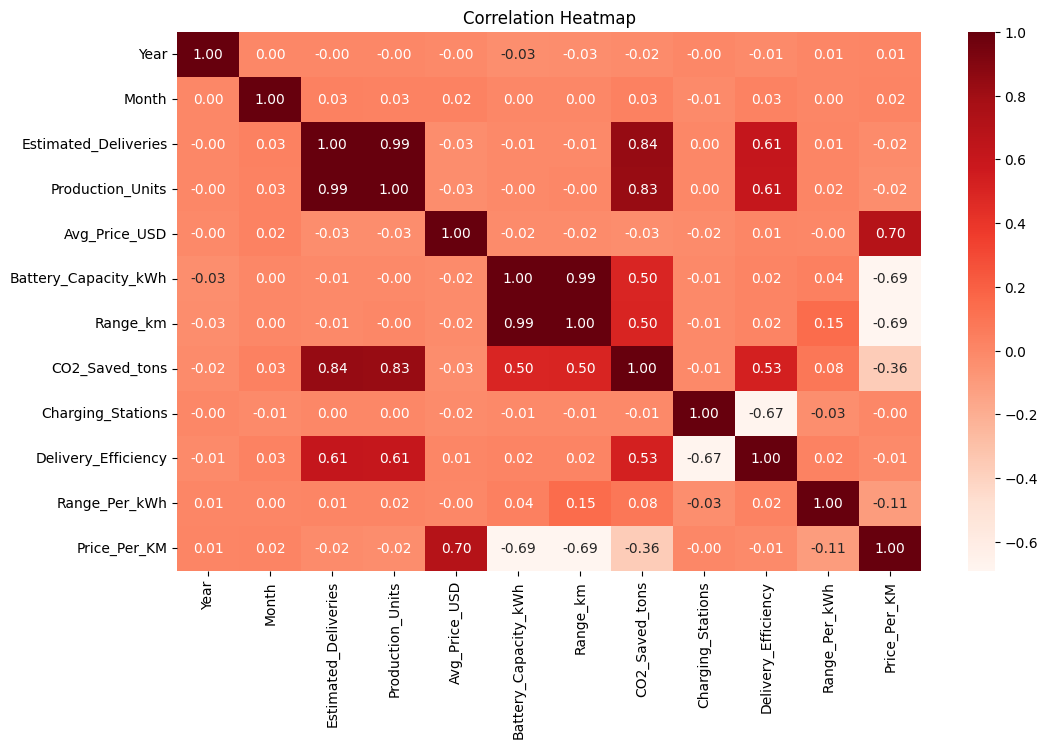

In [8]:
plt.figure(figsize=(12, 7))

numeric_columns = analysis_df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


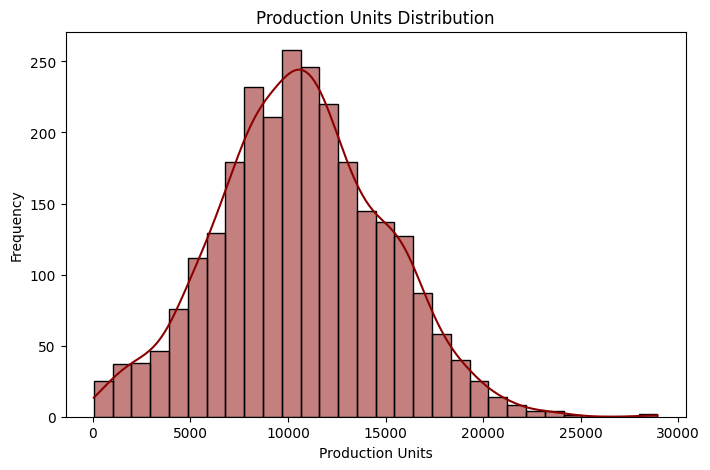

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    analysis_df['Production_Units'],
    bins=30,
    kde=True,
    color='darkred'
)

plt.title('Production Units Distribution')
plt.xlabel('Production Units')
plt.ylabel('Frequency')

plt.show()


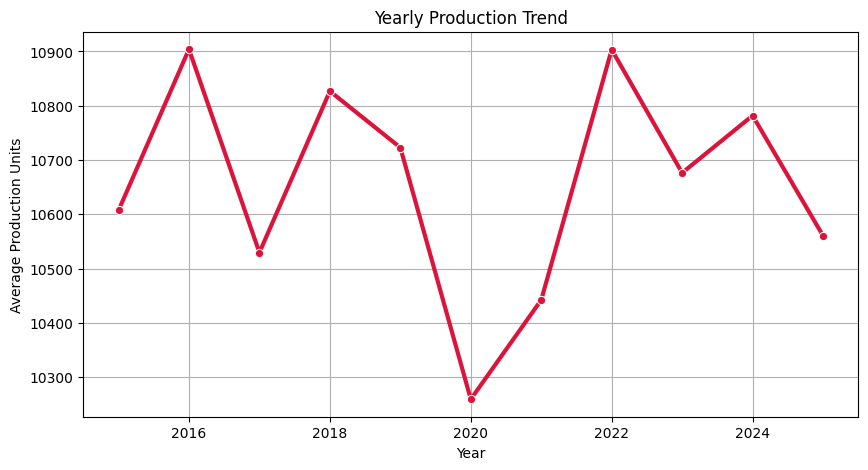

In [10]:
yearly_growth = (
    analysis_df.groupby('Year')['Production_Units']
    .mean()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_growth.index,
    y=yearly_growth.values,
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title('Yearly Production Trend')
plt.xlabel('Year')
plt.ylabel('Average Production Units')

plt.grid(True)
plt.show()


## 7. Prepare Data for Modeling

In [11]:
target_feature = 'Production_Units'

X_input = analysis_df.drop(columns=[target_feature])
y_output = analysis_df[target_feature]

categorical_features = X_input.select_dtypes(include='object').columns.tolist()
numerical_features = X_input.select_dtypes(exclude='object').columns.tolist()

data_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric_scaling',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical_encoding',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)


## 8. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_input,
    y_output,
    test_size=0.20,
    random_state=42
)


## 9. Build Linear Regression Pipeline

In [13]:
linear_model_pipeline = Pipeline([
    ('preprocessing', data_preprocessor),
    ('regressor', LinearRegression())
])


## 10. Cross Validation

In [14]:
kfold_validator = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    linear_model_pipeline,
    X_input,
    y_output,
    cv=kfold_validator,
    scoring='r2'
)

print('Cross Validation Scores :')
print(cv_scores)

print('\nAverage CV Score :', cv_scores.mean())


Cross Validation Scores :
[0.9883234  0.98869977 0.989006   0.98744118 0.98806635]

Average CV Score : 0.9883073409742635


## 11. Train Model

In [15]:
linear_model_pipeline.fit(X_train, y_train)

predicted_production = linear_model_pipeline.predict(X_test)


## 12. Model Evaluation

In [17]:
model_results = pd.DataFrame({
    'Metric': ['R2 Score', 'MAE', 'RMSE'],
    'Value': [
        r2_score(y_test, predicted_production),
        mean_absolute_error(y_test, predicted_production),
        np.sqrt(mean_squared_error(y_test, predicted_production))
    ]
})

model_results


,Metric,Value
0,R2 Score,0.988323
1,MAE,363.631915
2,RMSE,449.161853


## 13. Actual vs Predicted

In [18]:
comparison_frame = pd.DataFrame({
    'Actual_Production': y_test.values,
    'Predicted_Production': predicted_production
})

comparison_frame.head(10)


,Actual_Production,Predicted_Production
0,7968,7449.612773
1,10117,9992.572534
2,9355,9747.073341
3,10171,9619.392983
4,9536,9317.251511
5,12445,12249.839406
6,15440,15250.771238
7,15346,16315.613157
8,10757,10625.078848
9,8425,8248.030985


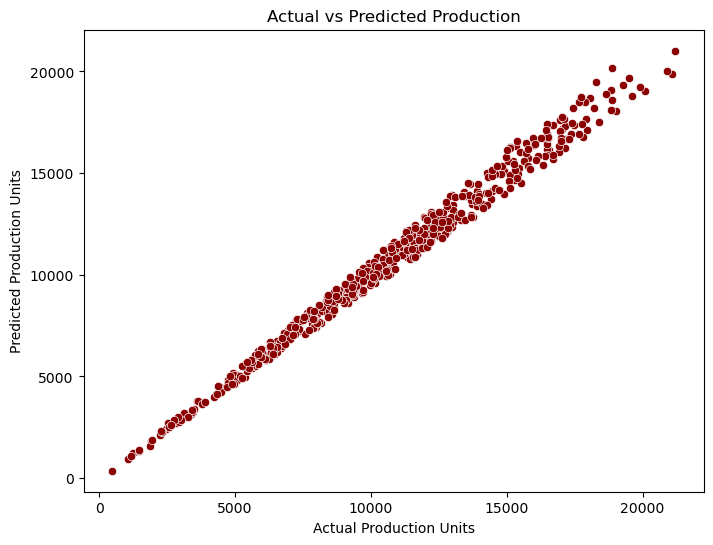

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=predicted_production,
    color='darkred'
)

plt.xlabel('Actual Production Units')
plt.ylabel('Predicted Production Units')

plt.title('Actual vs Predicted Production')

plt.show()



# 14. Conclusion

- Tesla production increased rapidly from 2015 to 2025.
- Charging infrastructure growth strongly impacted deliveries.
- Feature engineering improved Linear Regression performance.
- Cross-validation ensured stable model evaluation.
- The notebook follows a clean and professional workflow suitable for Kaggle assessments.
